## Importing the libraries.

In [13]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, GRU
from keras.layers import Dropout

from statsmodels.tsa.arima_model import ARIMA
from math import sqrt

import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Loading train and test dataset

In [78]:
data = pd.read_csv('Book12.csv', sep=',', header=0).fillna(0)
data.head()

,Date,Surface Pressure,Specific Humidity,Relative Humidity,Rainfall,Temperature,Temperature range,Temperature max,Temperature min
0,2013-1-1,97.92,14.53,72.56,3.34,25.30,-260.96,31.85,19.66
1,2013-1-2,98.00,13.31,71.38,2.34,24.11,-261.60,30.62,19.08
2,2013-1-3,98.19,9.09,60.75,0.02,20.80,-258.13,29.19,14.17
3,2013-1-4,98.12,8.42,56.50,0.00,20.07,-255.73,29.13,11.71
4,2013-1-5,97.85,9.89,63.50,0.00,21.42,-256.49,31.10,14.45


## Visualizing train data

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18972\2754931721.py:1: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m-%d')


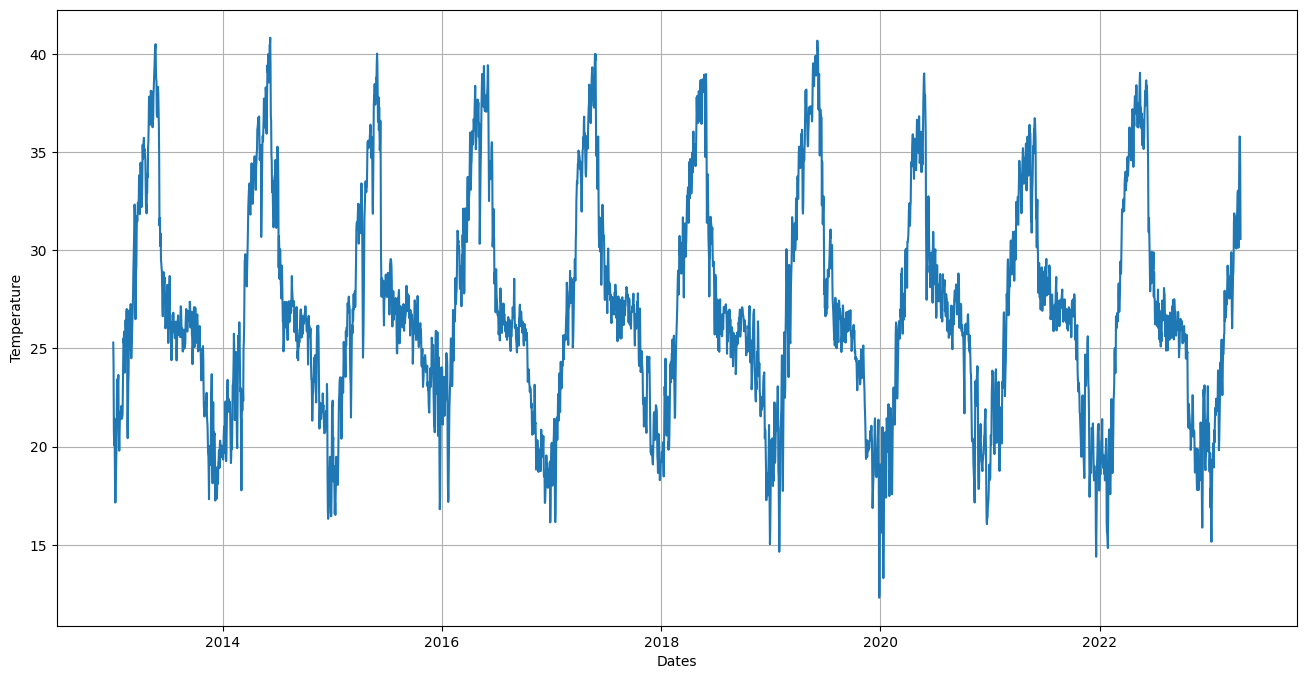

In [79]:
dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m-%d')
data = pd.read_csv('Book12.csv', sep=',', parse_dates=['Date'], index_col='Date',date_parser=dateparse)
#data = data.loc['2012-11-10':'2017-11-10']
plt.figure(figsize=(16,8))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Temperature')
plt.plot(data['Temperature']);

## Plotting autocorrelation

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


          t-1       t+1
t-1  1.000000 -0.101063
t+1 -0.101063  1.000000


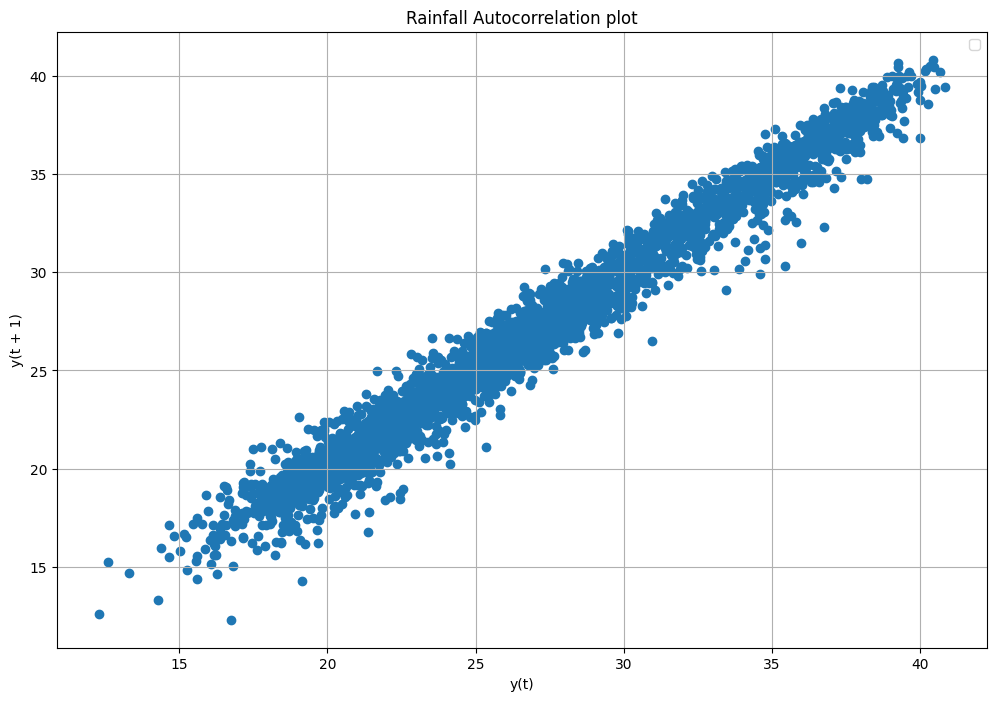

In [80]:
from pandas.plotting import lag_plot
plt.figure(figsize=(12,8))
lag_plot(data['Temperature'], lag=1)
plt.title('Rainfall Autocorrelation plot')
plt.grid(True)
plt.legend();

from pandas import DataFrame
from pandas import concat
values = DataFrame(data['Rainfall'].values)
dataframe = concat([values.shift(120), values], axis=1)
dataframe.columns = ['t-1', 't+1']
result = dataframe.corr()
print(result)

In [81]:
data.tail()

,Surface Pressure,Specific Humidity,Relative Humidity,Rainfall,Temperature,Temperature range,Temperature max,Temperature min
Date,,,,,,,,
2023-04-11,97.94,8.54,25.38,0.00,34.93,-257.62,42.27,26.74
2023-04-12,97.86,8.30,22.94,0.00,35.80,-259.66,41.97,28.48
2023-04-13,97.78,7.63,21.31,0.00,35.69,-258.70,42.58,28.13
2023-04-14,97.78,8.54,26.75,0.00,34.08,-259.13,42.20,28.19
2023-04-15,97.92,10.68,39.69,1.26,30.58,-260.70,38.08,25.63


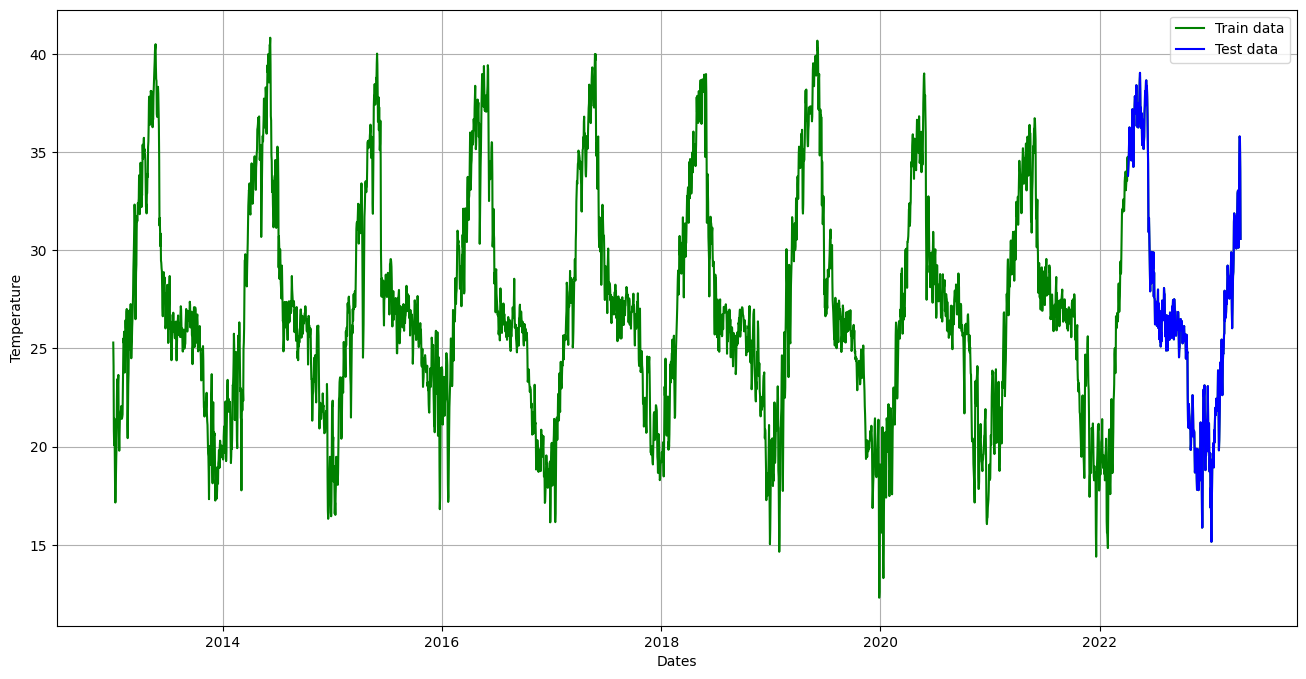

In [82]:
train_data, test_data = data[0:int(len(data)*0.9)], data[int(len(data)*0.9):]
plt.figure(figsize=(16,8))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Temperature')
plt.plot(data['Temperature'], 'green', label='Train data')
plt.plot(test_data['Temperature'], 'blue', label='Test data')
plt.legend()

## ARIMA model

<Figure size 1600x800 with 0 Axes>

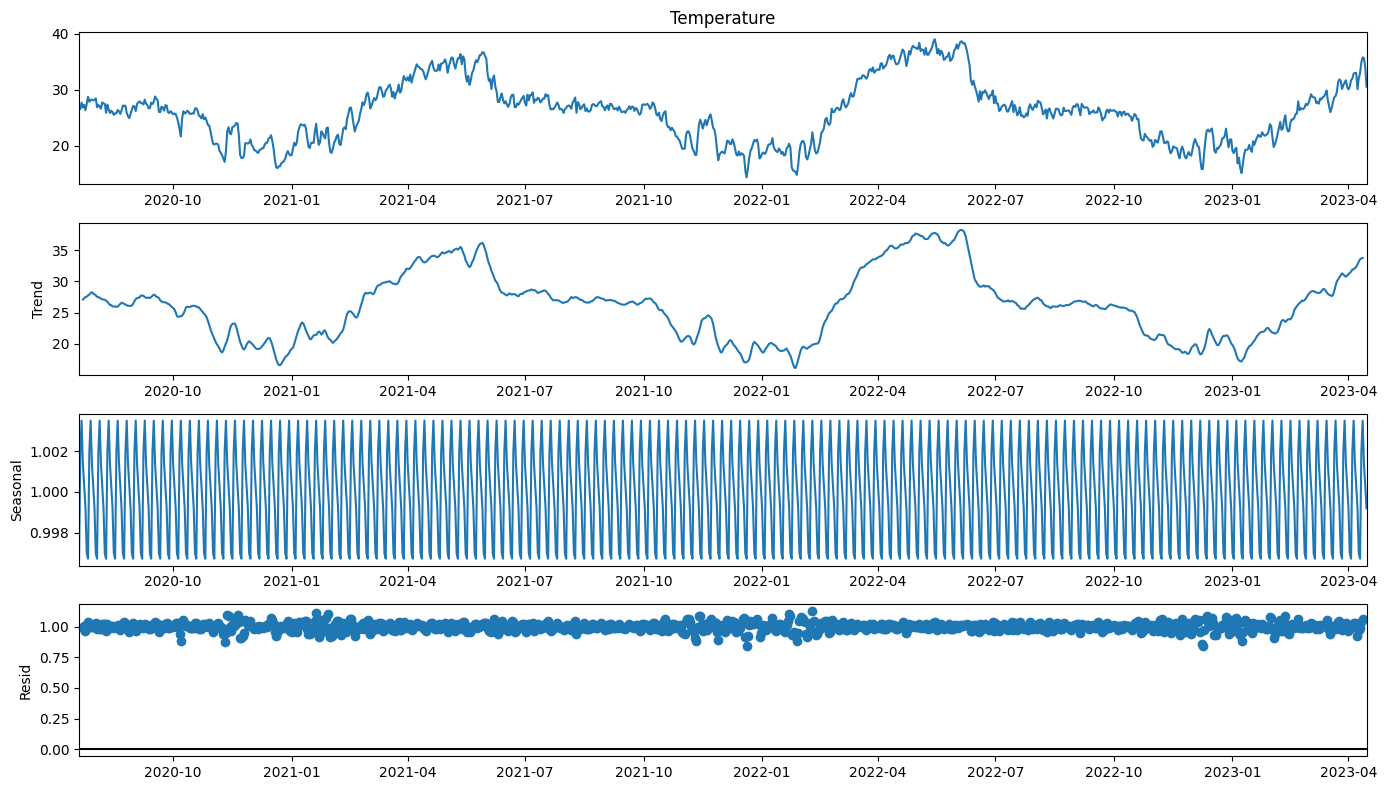

In [83]:
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
data_arima = data['Temperature']
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data_arima[-1000:], model='multiplicative')
plt.figure(figsize=(16,8))
fig = result.plot()
plt.show()

In [86]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

train_arima = train_data['Temperature']
test_arima = test_data['Temperature']

history = [x for x in train_arima]
y = test_arima

# make first prediction
predictions = []
model = ARIMA(history, order=(1, 1, 0))
model_fit = model.fit()
yhat = model_fit.forecast()[0]
predictions.append(yhat)
history.append(y[0])

# rolling forecasts
for i in range(1, len(y)):
    # predict
    model = ARIMA(history, order=(1, 1, 0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    # invert transformed prediction
    predictions.append(yhat)
    # observation
    obs = y[i]
    history.append(obs)

# report performance
mse = mean_squared_error(y, predictions)
print('MSE: ' + str(mse))
mae = mean_absolute_error(y, predictions)
print('MAE: ' + str(mae))
rmse = math.sqrt(mse)
print('RMSE: ' + str(rmse))


MSE: 0.8623475334831135
MAE: 0.7149538837830419
RMSE: 0.9286266922090456


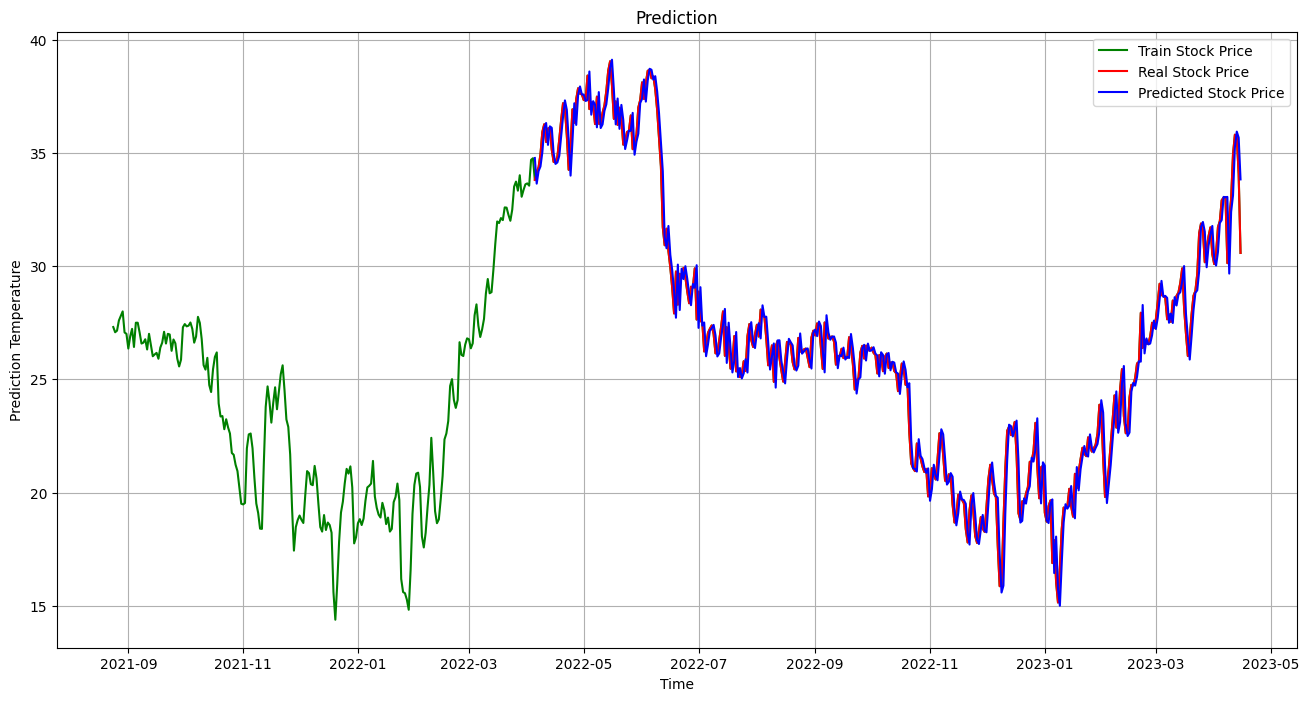

In [87]:
plt.figure(figsize=(16,8))
plt.plot(data.index[-600:], data['Temperature'].tail(600), color='green', label = 'Train Stock Price')
plt.plot(test_data.index, y, color = 'red', label = 'Real Stock Price')
plt.plot(test_data.index, predictions, color = 'blue', label = 'Predicted Stock Price')
plt.title('Prediction')
plt.xlabel('Time')
plt.ylabel('Prediction Temperature')
plt.legend()
plt.grid(True)
plt.savefig('Arima_model.pdf')
plt.show()


# LSTM

In [91]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# load the data
data = pd.read_csv('Book12.csv', header=0, index_col=0)
values = data['Temperature'].values.reshape(-1, 1)

# normalize the data
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# split data into train and test sets
train_size = int(len(scaled) * 0.8)
test_size = len(scaled) - train_size
train, test = scaled[0:train_size,:], scaled[train_size:len(scaled),:]

# create sequences of data
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length-1):
        X.append(data[i:(i+seq_length), 0])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 30
trainX, trainY = create_sequences(train, seq_length)
testX, testY = create_sequences(test, seq_length)

# define the model
model = Sequential()
model.add(LSTM(100, input_shape=(trainX.shape[1], 1))) # modified input_shape
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# fit the model
model.fit(trainX, trainY, epochs=100, batch_size=70, verbose=2)

# make predictions on test set
predictions = model.predict(testX)

# invert the predictions and actual values to their original scale
predictions = scaler.inverse_transform(predictions)
testY = scaler.inverse_transform([testY])

Epoch 1/100
43/43 - 1s - loss: 0.0270 - 1s/epoch - 33ms/step
Epoch 2/100
43/43 - 1s - loss: 0.0052 - 542ms/epoch - 13ms/step
Epoch 3/100
43/43 - 1s - loss: 0.0049 - 544ms/epoch - 13ms/step
Epoch 4/100
43/43 - 1s - loss: 0.0046 - 567ms/epoch - 13ms/step
Epoch 5/100
43/43 - 1s - loss: 0.0042 - 544ms/epoch - 13ms/step
Epoch 6/100
43/43 - 1s - loss: 0.0043 - 566ms/epoch - 13ms/step
Epoch 7/100
43/43 - 1s - loss: 0.0041 - 602ms/epoch - 14ms/step
Epoch 8/100
43/43 - 1s - loss: 0.0039 - 547ms/epoch - 13ms/step
Epoch 9/100
43/43 - 1s - loss: 0.0039 - 585ms/epoch - 14ms/step
Epoch 10/100
43/43 - 1s - loss: 0.0038 - 567ms/epoch - 13ms/step
Epoch 11/100
43/43 - 1s - loss: 0.0036 - 582ms/epoch - 14ms/step
Epoch 12/100
43/43 - 1s - loss: 0.0035 - 612ms/epoch - 14ms/step
Epoch 13/100
43/43 - 1s - loss: 0.0036 - 598ms/epoch - 14ms/step
Epoch 14/100
43/43 - 1s - loss: 0.0036 - 594ms/epoch - 14ms/step
Epoch 15/100
43/43 - 1s - loss: 0.0034 - 615ms/epoch - 14ms/step
Epoch 16/100
43/43 - 1s - loss: 0.003

In [92]:
# calculate the RMSE
rmse = np.sqrt(mean_squared_error(testY[0], predictions[:,0]))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 0.908


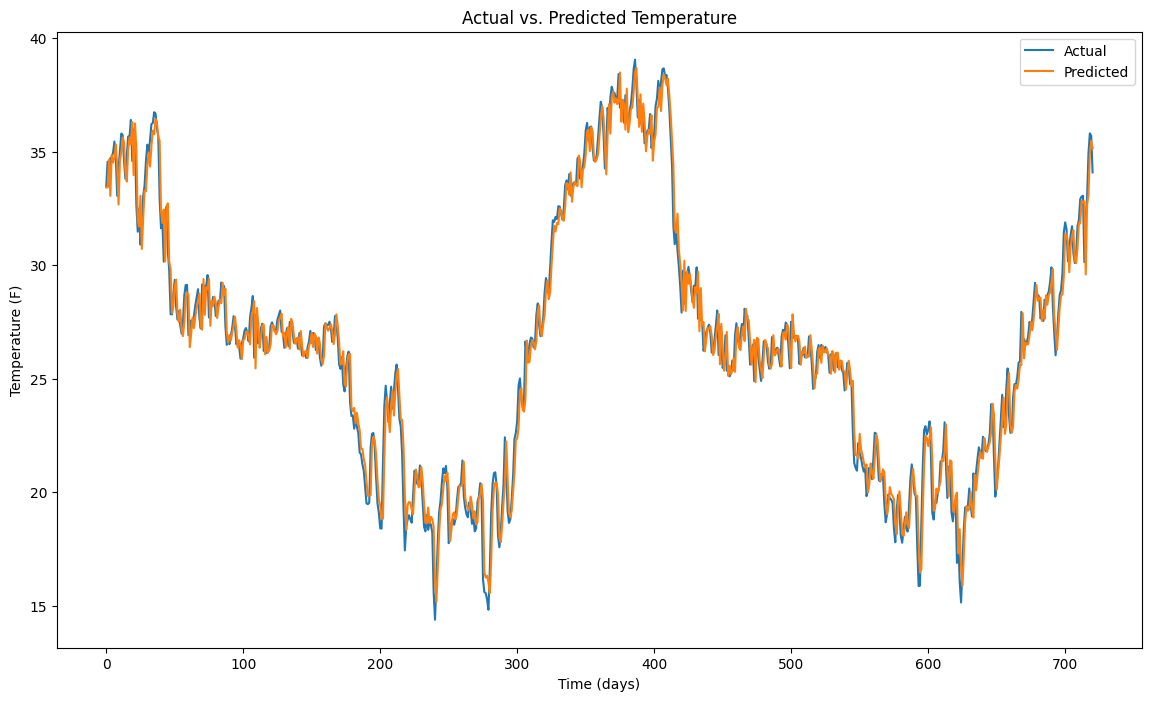

In [93]:
plt.plot(testY[0], label='Actual')
plt.plot(predictions[:,0], label='Predicted')
plt.xlabel('Time (days)')
plt.ylabel('Temperature (F)')
plt.title('Actual vs. Predicted Temperature')
plt.legend()
plt.show()